In [8]:
import re
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns


LAYER_TYPES = ("layer_z", "tri_att_start", "tri_att_end")


def _key(layer_n: int, layer_type: str) -> str:
    return f"pairformer_{layer_n}_{layer_type}"


def get_layer_ids(reps: dict, step: str, layer_type: str = "layer_z") -> list[int]:
    """Sorted pairformer layer indices available for a given step/type."""
    pat = re.compile(rf"pairformer_(\d+)_{layer_type}$")
    return sorted({int(m.group(1)) for k in reps[step] if (m := pat.match(k))})


def get_tensor(reps: dict, step: str, layer_n: int, layer_type: str = "layer_z") -> torch.Tensor:
    """Return the [N, N, D] tensor (batch squeezed) for a given step/layer."""
    return reps[step][_key(layer_n, layer_type)].squeeze(0)


def plot_layer(reps: dict, step: str, layer_n: int, layer_type: str = "layer_z",
               ax=None, cmap: str = "viridis"):
    """Heatmap of the L2 norm over the feature dim for a single layer."""
    m = get_tensor(reps, step, layer_n, layer_type).norm(dim=-1).cpu().numpy()
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4.5))
    sns.heatmap(m, ax=ax, cmap=cmap, square=True, xticklabels=False, yticklabels=False)
    ax.set_title(f"{step} | {layer_type} | layer {layer_n}")
    return ax


def plot_layers_grid(reps: dict, step: str, layer_type: str = "layer_z",
                     reduce: str = "norm", cmap: str = "viridis", ncols: int = 4):
    """Grid of heatmaps across all layers for a given step/type.

    reduce: 'norm' -> L2 over feature dim; 'mean' -> mean over feature dim.
    """
    layer_ids = get_layer_ids(reps, step, layer_type)
    mats = []
    for lid in layer_ids:
        t = get_tensor(reps, step, lid, layer_type)
        m = (t.norm(dim=-1) if reduce == "norm" else t.mean(dim=-1)).cpu().numpy()
        mats.append((lid, m))
    vmin = min(m.min() for _, m in mats)
    vmax = max(m.max() for _, m in mats)
    norm = plt.Normalize(vmin, vmax)

    nrows = (len(mats) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)
    for ax, (lid, m) in zip(axes.flat, mats):
        sns.heatmap(m, ax=ax, cbar=False, cmap=cmap, norm=norm, square=True,
                    xticklabels=False, yticklabels=False)
        ax.set_title(f"layer {lid}")
    for ax in axes.flat[len(mats):]:
        ax.axis("off")

    fig.subplots_adjust(right=0.88)
    cax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    fig.colorbar(sm, cax=cax).set_label(reduce)
    fig.suptitle(f"{step} | {layer_type} ({reduce})", fontsize=18)
    return fig, axes


def cosine_map(reps_a: dict, reps_b: dict, step: str, layer_n: int,
               layer_type: str = "layer_z") -> np.ndarray:
    """Per-pair cosine similarity [N, N] between two representations."""
    a = get_tensor(reps_a, step, layer_n, layer_type)
    b = get_tensor(reps_b, step, layer_n, layer_type)
    return torch.nn.functional.cosine_similarity(a, b, dim=-1).cpu().numpy()


def plot_cosine_grid(reps_a: dict, reps_b: dict, step: str,
                     layer_type: str = "layer_z", cmap: str = "magma", ncols: int = 4):
    """Grid of per-pair cosine-similarity heatmaps across layers."""
    layer_ids = get_layer_ids(reps_a, step, layer_type)
    mats = [(lid, cosine_map(reps_a, reps_b, step, lid, layer_type)) for lid in layer_ids]
    vmin = min(m.min() for _, m in mats)
    vmax = max(m.max() for _, m in mats)
    norm = plt.Normalize(vmin, vmax)

    nrows = (len(mats) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)
    for ax, (lid, m) in zip(axes.flat, mats):
        sns.heatmap(m, ax=ax, cbar=False, cmap=cmap, norm=norm, square=True,
                    xticklabels=False, yticklabels=False)
        ax.set_title(f"layer {lid}")
    for ax in axes.flat[len(mats):]:
        ax.axis("off")

    fig.subplots_adjust(right=0.88)
    cax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    fig.colorbar(sm, cax=cax).set_label("cosine similarity")
    fig.suptitle(f"cosine similarity | {step} | {layer_type}", fontsize=18)
    return fig, axes


def plot_cosine_trend(reps_a: dict, reps_b: dict, step: str,
                      layer_type: str = "layer_z", ax=None):
    """Scalar (mean/median over pairs) cosine similarity vs layer depth."""
    layer_ids = get_layer_ids(reps_a, step, layer_type)
    means, medians = [], []
    for lid in layer_ids:
        cs = cosine_map(reps_a, reps_b, step, lid, layer_type)
        means.append(cs.mean()); medians.append(np.median(cs))
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    ax.plot(layer_ids, means, marker="o", label="mean")
    ax.plot(layer_ids, medians, marker="s", linestyle="--", label="median")
    ax.set_xlabel("pairformer layer"); ax.set_ylabel("cosine similarity")
    ax.set_title(f"{step} | {layer_type}"); ax.grid(alpha=0.3); ax.legend()
    return ax, layer_ids, np.array(means), np.array(medians)


def plot_cosine_trend_by_type(reps_a: dict, reps_b: dict, step: str,
                              layer_types=LAYER_TYPES, ax=None, palette=None):
    """Overlay mean per-pair cosine similarity vs layer depth, one line per layer_type."""
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4.5))
    if palette is None:
        palette = dict(zip(layer_types, sns.color_palette("tab10", len(layer_types))))
    out = {}
    for lt in layer_types:
        layer_ids = get_layer_ids(reps_a, step, lt)
        if not layer_ids:
            continue
        means = np.array([cosine_map(reps_a, reps_b, step, lid, lt).mean() for lid in layer_ids])
        ax.plot(layer_ids, means, marker="o", color=palette[lt], label=lt)
        out[lt] = (np.array(layer_ids), means)
    ax.set_xlabel("pairformer layer")
    ax.set_ylabel("mean cosine similarity")
    ax.set_title(f"{step} | cosine similarity by layer type")
    ax.grid(alpha=0.3)
    ax.legend()
    return ax, out


In [12]:
hidden_representations.keys()

dict_keys(['step_0', 'step_5', 'step_10'])

In [7]:
for key, item in hidden_representations["step_0"].items():
    print(f"key: {key}, item.shape: {item.shape}")


key: pairformer_0_tri_att_start, item.shape: torch.Size([1, 238, 238, 128])
key: pairformer_0_tri_att_end, item.shape: torch.Size([1, 238, 238, 128])
key: pairformer_0_layer_z, item.shape: torch.Size([1, 238, 238, 128])
key: pairformer_11_tri_att_start, item.shape: torch.Size([1, 238, 238, 128])
key: pairformer_11_tri_att_end, item.shape: torch.Size([1, 238, 238, 128])
key: pairformer_11_layer_z, item.shape: torch.Size([1, 238, 238, 128])
key: pairformer_23_tri_att_start, item.shape: torch.Size([1, 238, 238, 128])
key: pairformer_23_tri_att_end, item.shape: torch.Size([1, 238, 238, 128])
key: pairformer_23_layer_z, item.shape: torch.Size([1, 238, 238, 128])
key: pairformer_35_tri_att_start, item.shape: torch.Size([1, 238, 238, 128])
key: pairformer_35_tri_att_end, item.shape: torch.Size([1, 238, 238, 128])
key: pairformer_35_layer_z, item.shape: torch.Size([1, 238, 238, 128])
key: pairformer_47_tri_att_start, item.shape: torch.Size([1, 238, 238, 128])
key: pairformer_47_tri_att_end, it

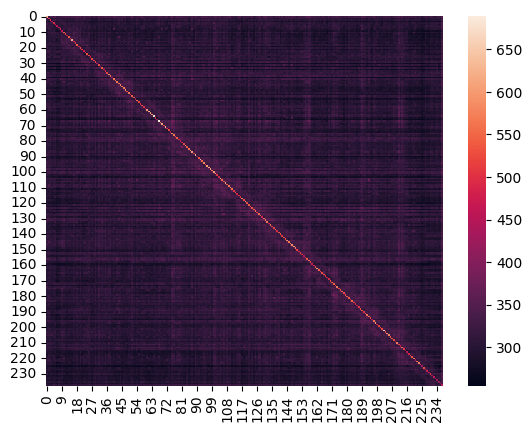

In [49]:
rep = hidden_representations["step_0"]["pairformer_11_layer_z"].squeeze(0).norm(dim=-1).cpu().numpy()
sns.heatmap(rep)
plt.show()


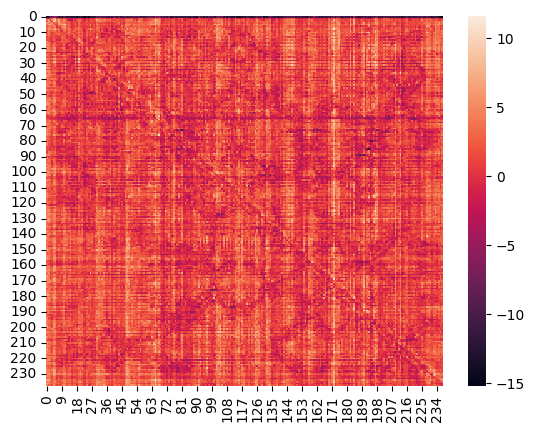

In [40]:
# difference between layers: 
diff = hidden_representations["step_5"]["pairformer_11_tri_att_end"].squeeze(0).norm(dim=-1).cpu().numpy() - hidden_representations["step_5"]["pairformer_11_tri_att_start"].squeeze(0).norm(dim=-1).cpu().numpy()
sns.heatmap(diff)
plt.show()


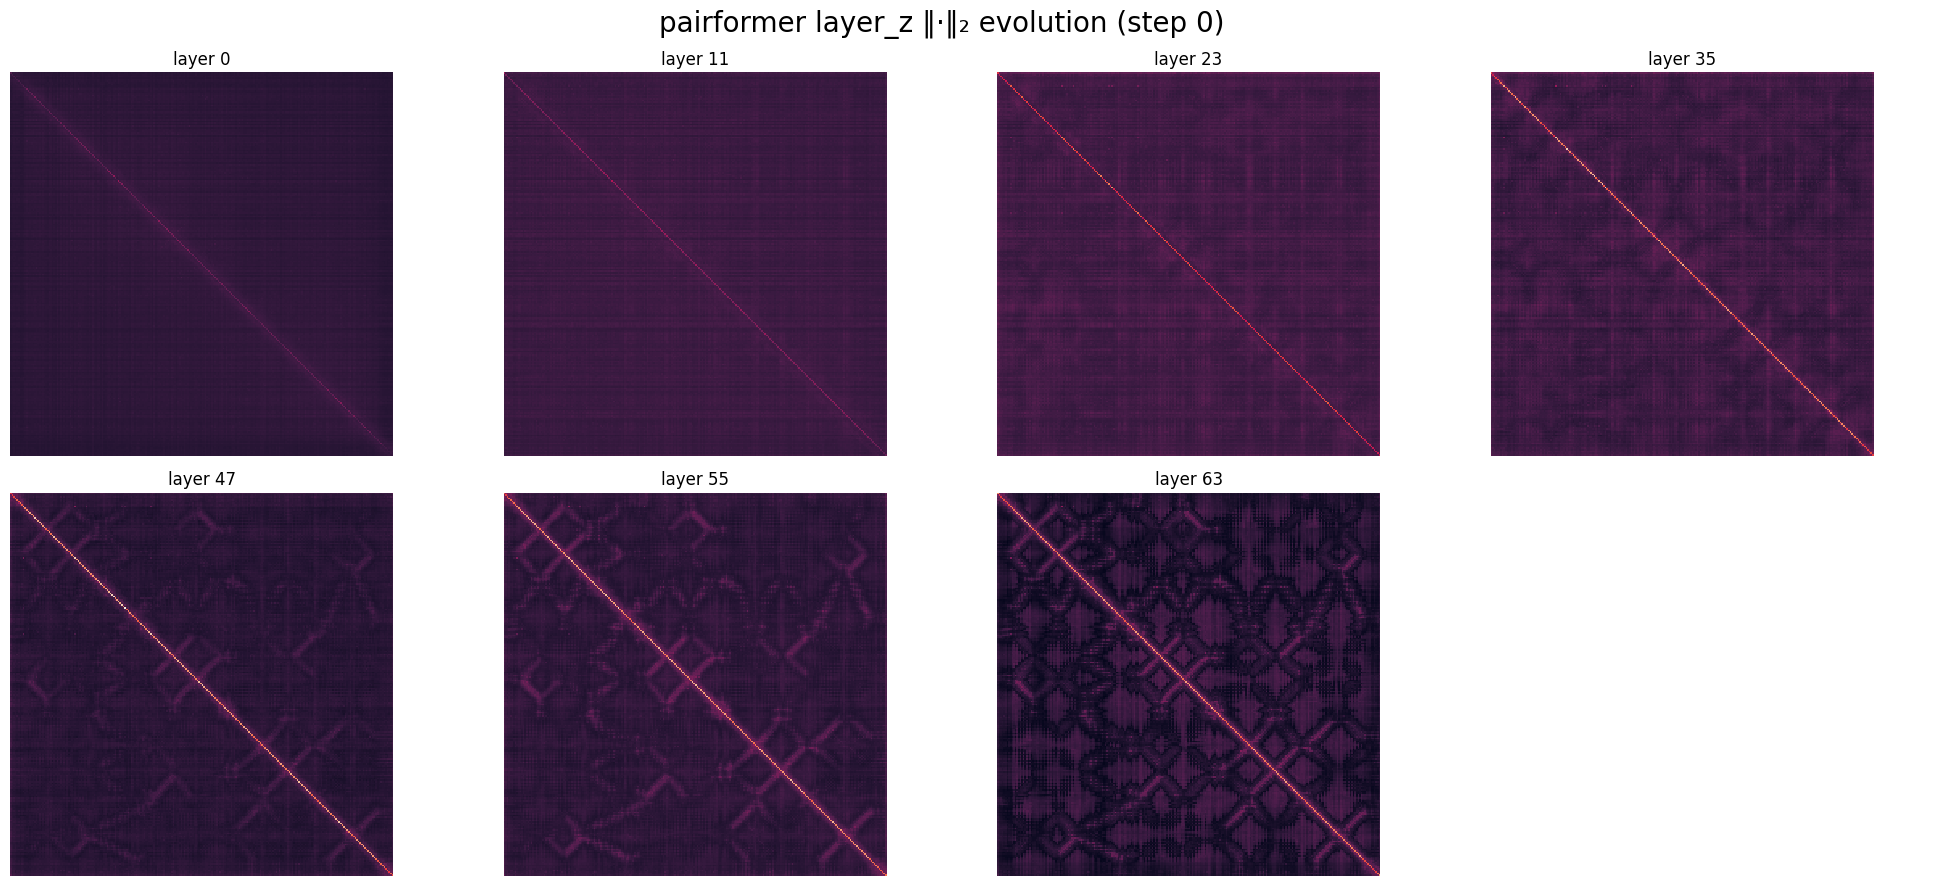

In [54]:
import re

step = hidden_representations["step_0"]
layer_ids = sorted(
    {int(m.group(1)) for k in step if (m := re.match(r"pairformer_(\d+)_layer_z$", k))}
)

n = len(layer_ids)
ncols = min(n, 4)
nrows = (n + ncols - 1) // ncols
# Increase the figure size by multiplying the base size
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)

vmin, vmax = None, None
mats = []
for lid in layer_ids:
    m = step[f"pairformer_{lid}_layer_z"].squeeze(0).norm(dim=-1).cpu().numpy()
    mats.append((lid, m))
vmin = min(m.min() for _, m in mats)
vmax = max(m.max() for _, m in mats)

for ax, (lid, m) in zip(axes.flat, mats):
    sns.heatmap(m, ax=ax, cbar=False, vmin=vmin, vmax=vmax, square=True,
                xticklabels=False, yticklabels=False)
    ax.set_title(f"layer {lid}")
for ax in axes.flat[len(mats):]:
    ax.axis("off")

fig.suptitle("pairformer layer_z ‖·‖₂ evolution (step 0)", fontsize=20)
fig.tight_layout()
plt.show()

## Comparision with the Original

In [55]:
original_rep = torch.load("/Users/thomasbush/Downloads/pairformer/original/pairformer/original/hidden_reps.pt")

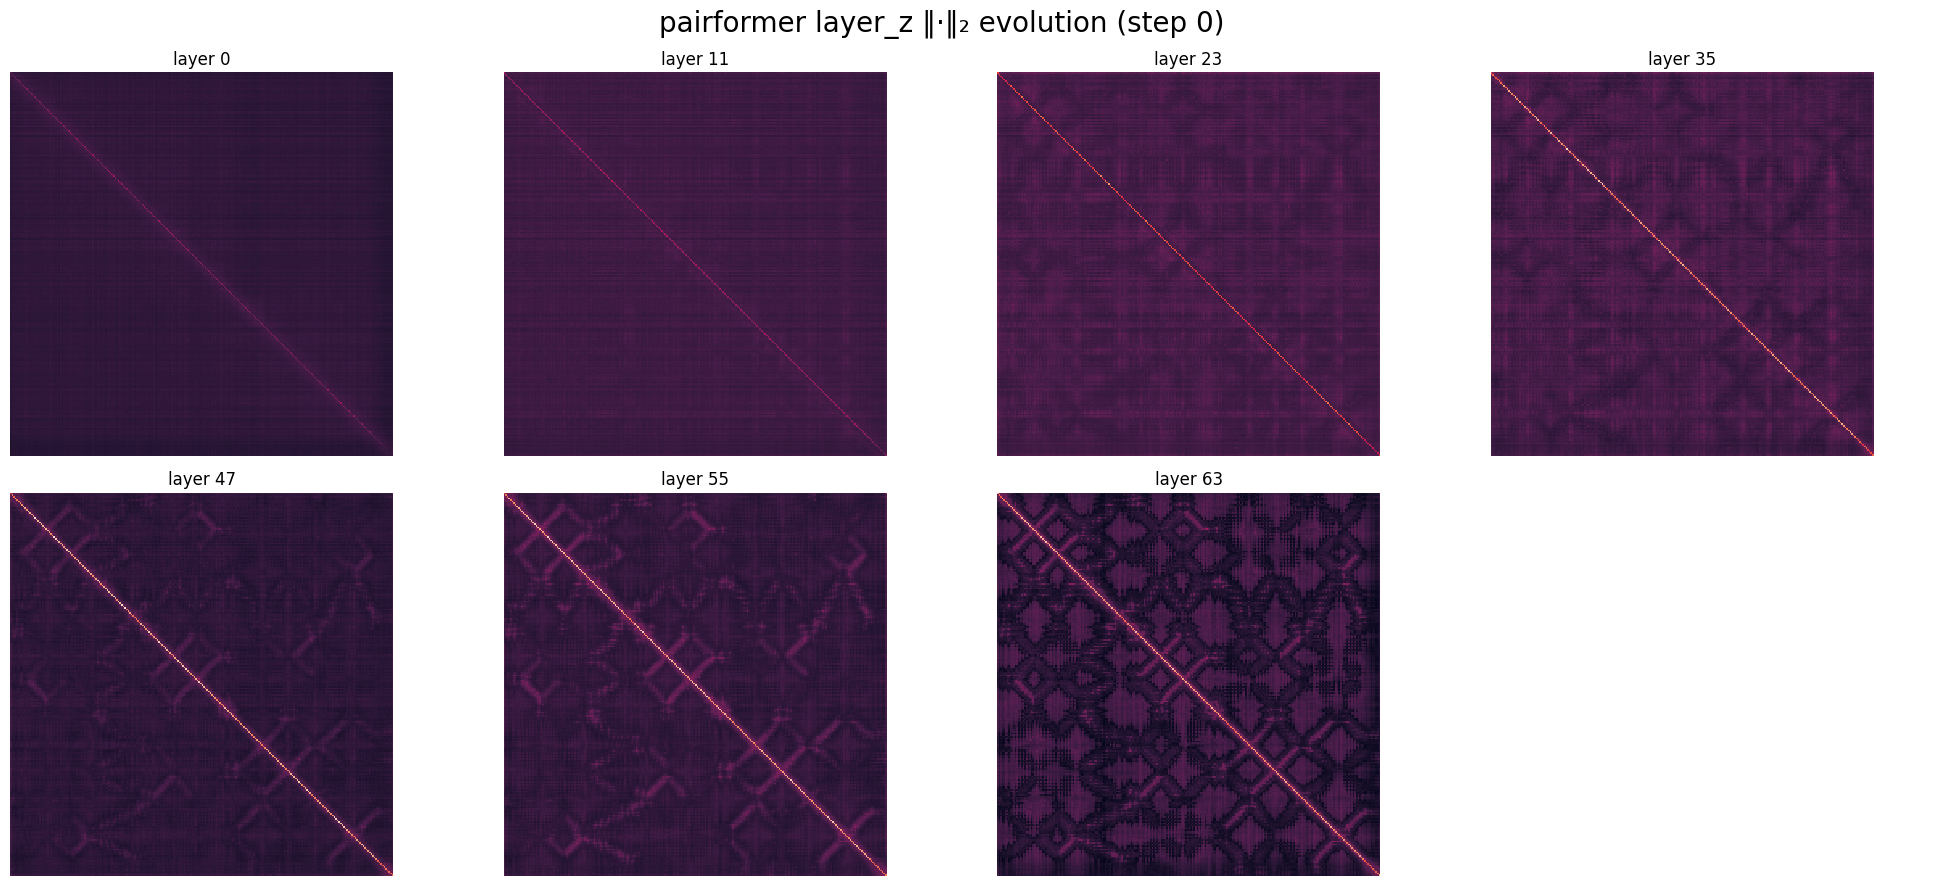

In [58]:
import re

step = original_rep["step_0"]
layer_ids = sorted(
    {int(m.group(1)) for k in step if (m := re.match(r"pairformer_(\d+)_layer_z$", k))}
)

n = len(layer_ids)
ncols = min(n, 4)
nrows = (n + ncols - 1) // ncols
# Increase the figure size by multiplying the base size
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)

vmin, vmax = None, None
mats = []
for lid in layer_ids:
    m = step[f"pairformer_{lid}_layer_z"].squeeze(0).norm(dim=-1).cpu().numpy()
    mats.append((lid, m))
vmin = min(m.min() for _, m in mats)
vmax = max(m.max() for _, m in mats)

for ax, (lid, m) in zip(axes.flat, mats):
    sns.heatmap(m, ax=ax, cbar=False, vmin=vmin, vmax=vmax, square=True,
                xticklabels=False, yticklabels=False)
    ax.set_title(f"layer {lid}")
for ax in axes.flat[len(mats):]:
    ax.axis("off")

fig.suptitle("pairformer layer_z ‖·‖₂ evolution (step 0)", fontsize=20)
fig.tight_layout()
plt.show()

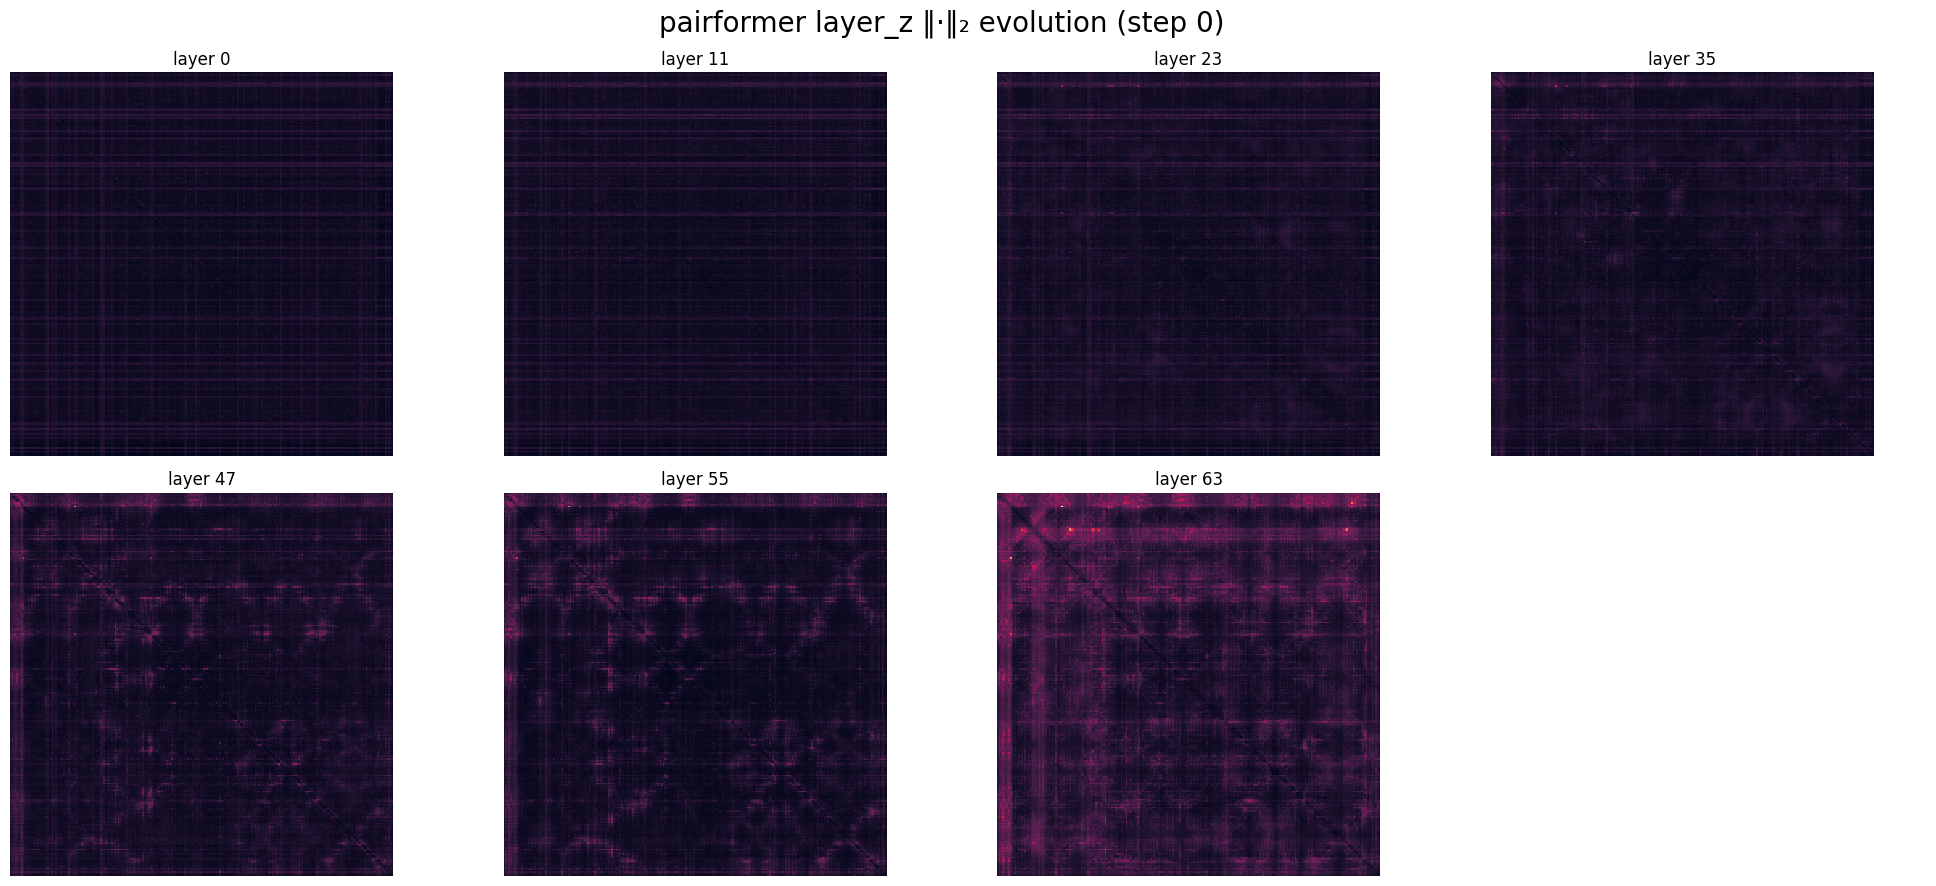

In [59]:
step = hidden_representations["step_0"]
step_original = original_rep["step_0"]
layer_ids = sorted(
    {int(m.group(1)) for k in step if (m := re.match(r"pairformer_(\d+)_layer_z$", k))}
)

n = len(layer_ids)
ncols = min(n, 4)
nrows = (n + ncols - 1) // ncols
# Increase the figure size by multiplying the base size
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)

vmin, vmax = None, None
mats = []
for lid in layer_ids:
    m = step[f"pairformer_{lid}_layer_z"].squeeze(0)
    m_original = step_original[f"pairformer_{lid}_layer_z"].squeeze(0)
    diff = (m - m_original).norm(dim=-1).cpu().numpy() / m_original.norm(dim=-1).cpu().numpy()
    mats.append((lid, diff))
vmin = min(diff.min() for _, diff in mats)
vmax = max(diff.max() for _, diff in mats)

for ax, (lid, diff) in zip(axes.flat, mats):
    sns.heatmap(diff, ax=ax, cbar=False, vmin=vmin, vmax=vmax, square=True,
                xticklabels=False, yticklabels=False)
    ax.set_title(f"layer {lid}")
for ax in axes.flat[len(mats):]:
    ax.axis("off")

fig.suptitle("pairformer layer_z ‖·‖₂ evolution (step 0)", fontsize=20)
fig.tight_layout()
plt.show()

/var/folders/0m/4nz5dl3956v2_pcbzw2lwtwr0000gn/T/ipykernel_89036/2387649884.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.88, 1])  # leave space for colorbar


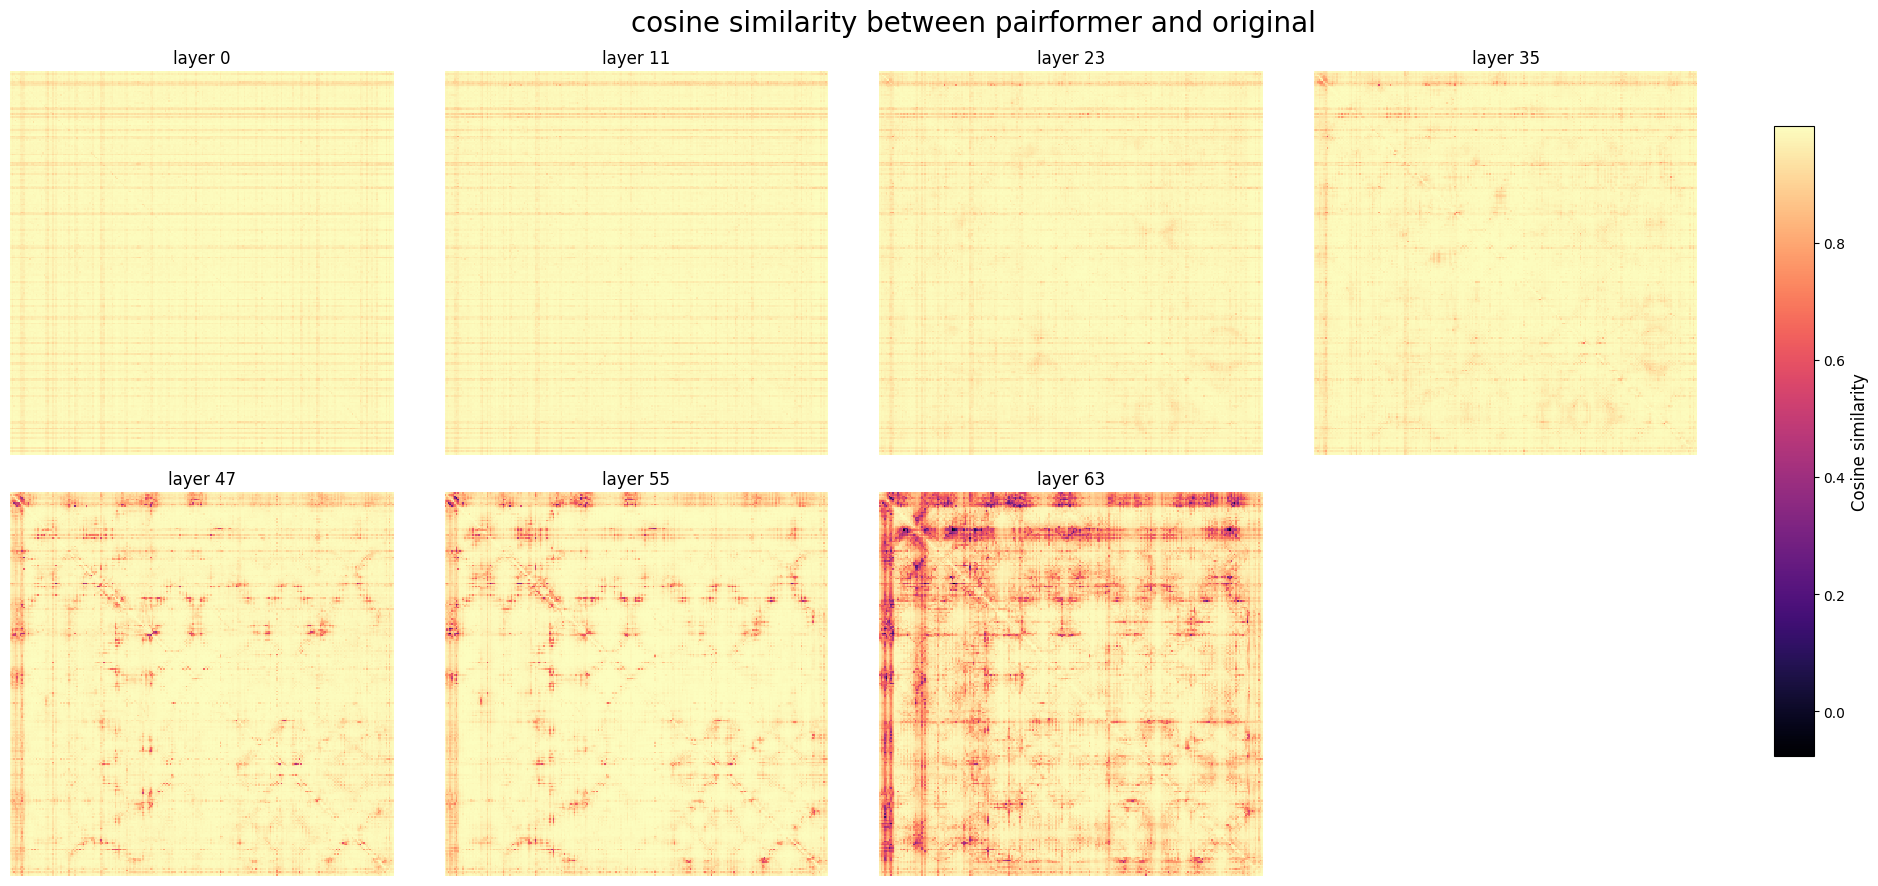

In [73]:
step = hidden_representations["step_0"]
step_original = original_rep["step_0"]
layer_ids = sorted(
    {int(m.group(1)) for k in step if (m := re.match(r"pairformer_(\d+)_layer_z$", k))}
)

n = len(layer_ids)
ncols = min(n, 4)
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)

mats = []
for lid in layer_ids:
    m = step[f"pairformer_{lid}_layer_z"].squeeze(0)
    m_original = step_original[f"pairformer_{lid}_layer_z"].squeeze(0)
    cosine_similarity = (m * m_original).sum(dim=-1).cpu().numpy() / (m.norm(dim=-1).cpu().numpy() * m_original.norm(dim=-1).cpu().numpy())
    mats.append((lid, cosine_similarity))
vmin = min(cosine_similarity.min() for _, cosine_similarity in mats)
vmax = max(cosine_similarity.max() for _, cosine_similarity in mats)

cmap = 'magma'
norm = plt.Normalize(vmin, vmax)

# Draw heatmaps without colorbars, using same norm/cmap as the colorbar
for ax, (lid, diff) in zip(axes.flat, mats):
    sns.heatmap(diff, ax=ax, cbar=False, vmin=vmin, vmax=vmax, square=True,
                cmap=cmap, norm=norm, xticklabels=False, yticklabels=False)
    ax.set_title(f"layer {lid}")
for ax in axes.flat[len(mats):]:
    ax.axis("off")

# Add a dedicated colorbar to the figure, using the *same* cmap and norm as the heatmaps
import matplotlib as mpl
cbar_mappable = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar_mappable.set_array([])  # Required for Matplotlib >= 3.1

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = plt.colorbar(cbar_mappable, cax=cbar_ax)
cbar.set_label('Cosine similarity', fontsize=12)

fig.suptitle("cosine similarity between pairformer and original", fontsize=20)
# tight_layout does not always work with extra colorbar axes, so let's be gentle:
try:
    fig.tight_layout(rect=[0, 0, 0.88, 1])  # leave space for colorbar
except Exception as e:
    print(f"Warning (tight_layout): {e}")
plt.show()

/var/folders/0m/4nz5dl3956v2_pcbzw2lwtwr0000gn/T/ipykernel_89036/2105389817.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.88, 1])  # leave space for colorbar


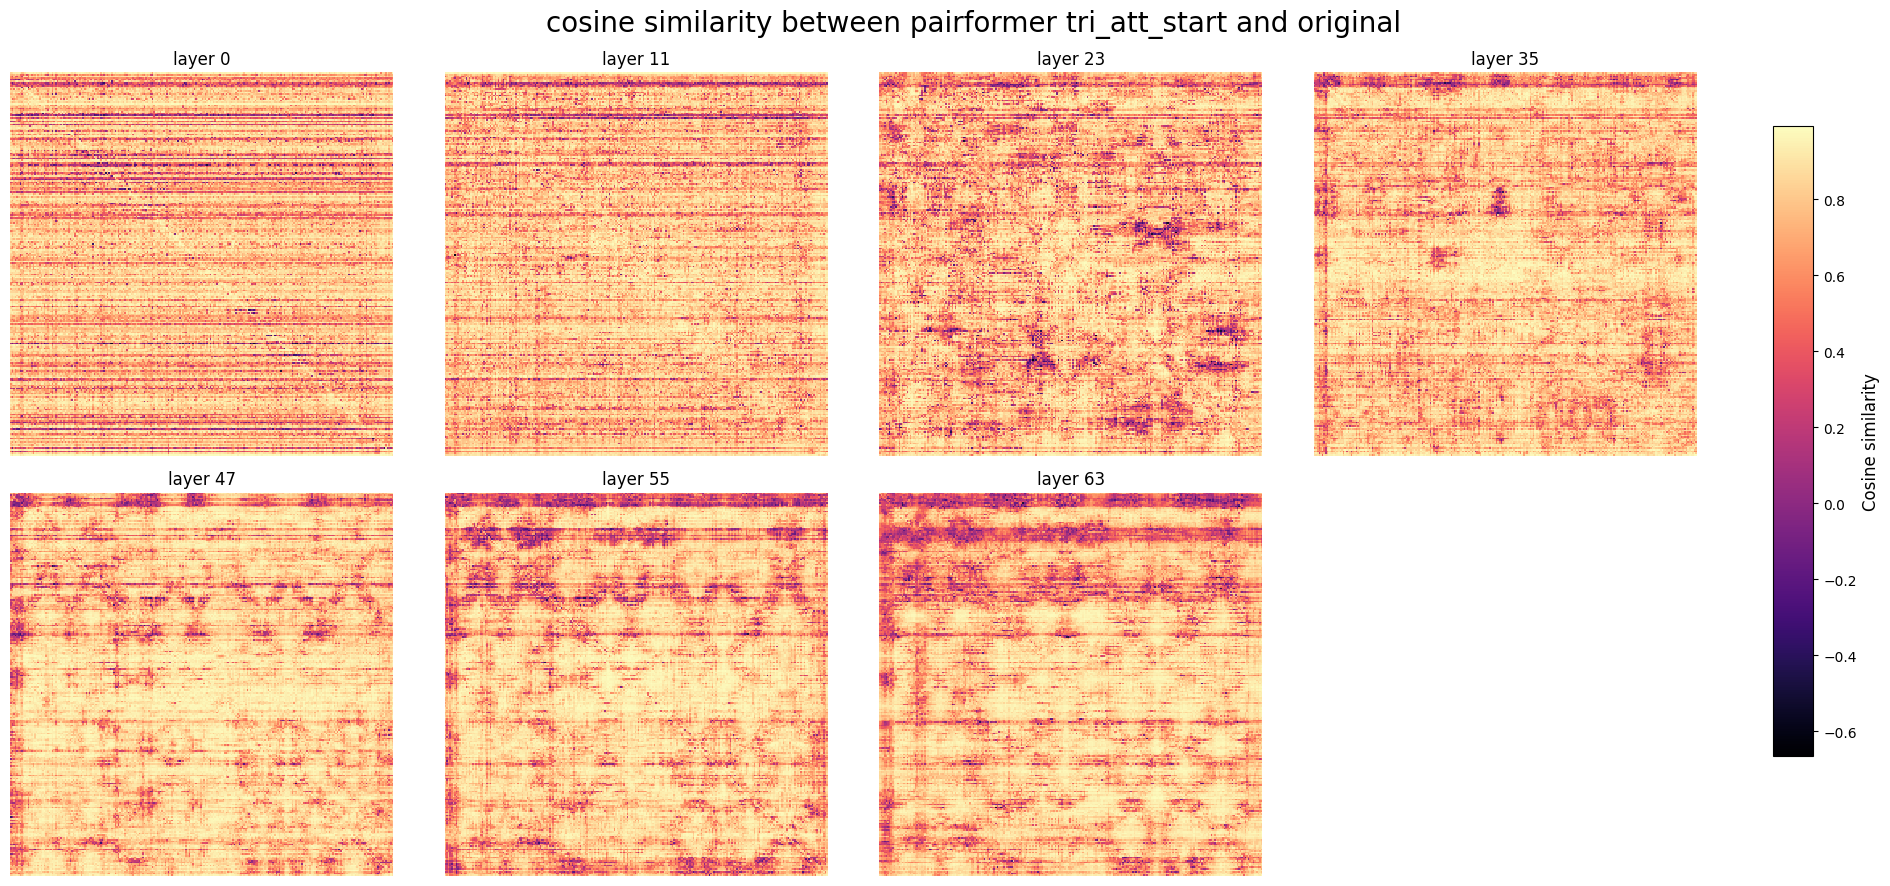

In [74]:
step = hidden_representations["step_0"]
step_original = original_rep["step_0"]

# Use 'pairformer_{i}_tri_att_start' keys for layer IDs instead of 'pairformer_{i}_layer_z'
layer_ids = sorted(
    {int(m.group(1)) for k in step if (m := re.match(r"pairformer_(\d+)_tri_att_start$", k))}
)

n = len(layer_ids)
ncols = min(n, 4)
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)

mats = []
for lid in layer_ids:
    m = step[f"pairformer_{lid}_tri_att_start"].squeeze(0)
    m_original = step_original[f"pairformer_{lid}_tri_att_start"].squeeze(0)
    cosine_similarity = (m * m_original).sum(dim=-1).cpu().numpy() / (m.norm(dim=-1).cpu().numpy() * m_original.norm(dim=-1).cpu().numpy())
    mats.append((lid, cosine_similarity))
vmin = min(cosine_similarity.min() for _, cosine_similarity in mats)
vmax = max(cosine_similarity.max() for _, cosine_similarity in mats)

cmap = 'magma'
norm = plt.Normalize(vmin, vmax)

# Draw heatmaps without colorbars, using same norm/cmap as the colorbar
for ax, (lid, diff) in zip(axes.flat, mats):
    sns.heatmap(diff, ax=ax, cbar=False, vmin=vmin, vmax=vmax, square=True,
                cmap=cmap, norm=norm, xticklabels=False, yticklabels=False)
    ax.set_title(f"layer {lid}")
for ax in axes.flat[len(mats):]:
    ax.axis("off")

# Add a dedicated colorbar to the figure, using the *same* cmap and norm as the heatmaps
import matplotlib as mpl
cbar_mappable = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar_mappable.set_array([])  # Required for Matplotlib >= 3.1

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = plt.colorbar(cbar_mappable, cax=cbar_ax)
cbar.set_label('Cosine similarity', fontsize=12)

fig.suptitle("cosine similarity between pairformer tri_att_start and original", fontsize=20)
# tight_layout does not always work with extra colorbar axes, so let's be gentle:
try:
    fig.tight_layout(rect=[0, 0, 0.88, 1])  # leave space for colorbar
except Exception as e:
    print(f"Warning (tight_layout): {e}")
plt.show()

/var/folders/0m/4nz5dl3956v2_pcbzw2lwtwr0000gn/T/ipykernel_89036/699824525.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.88, 1])  # leave space for colorbar


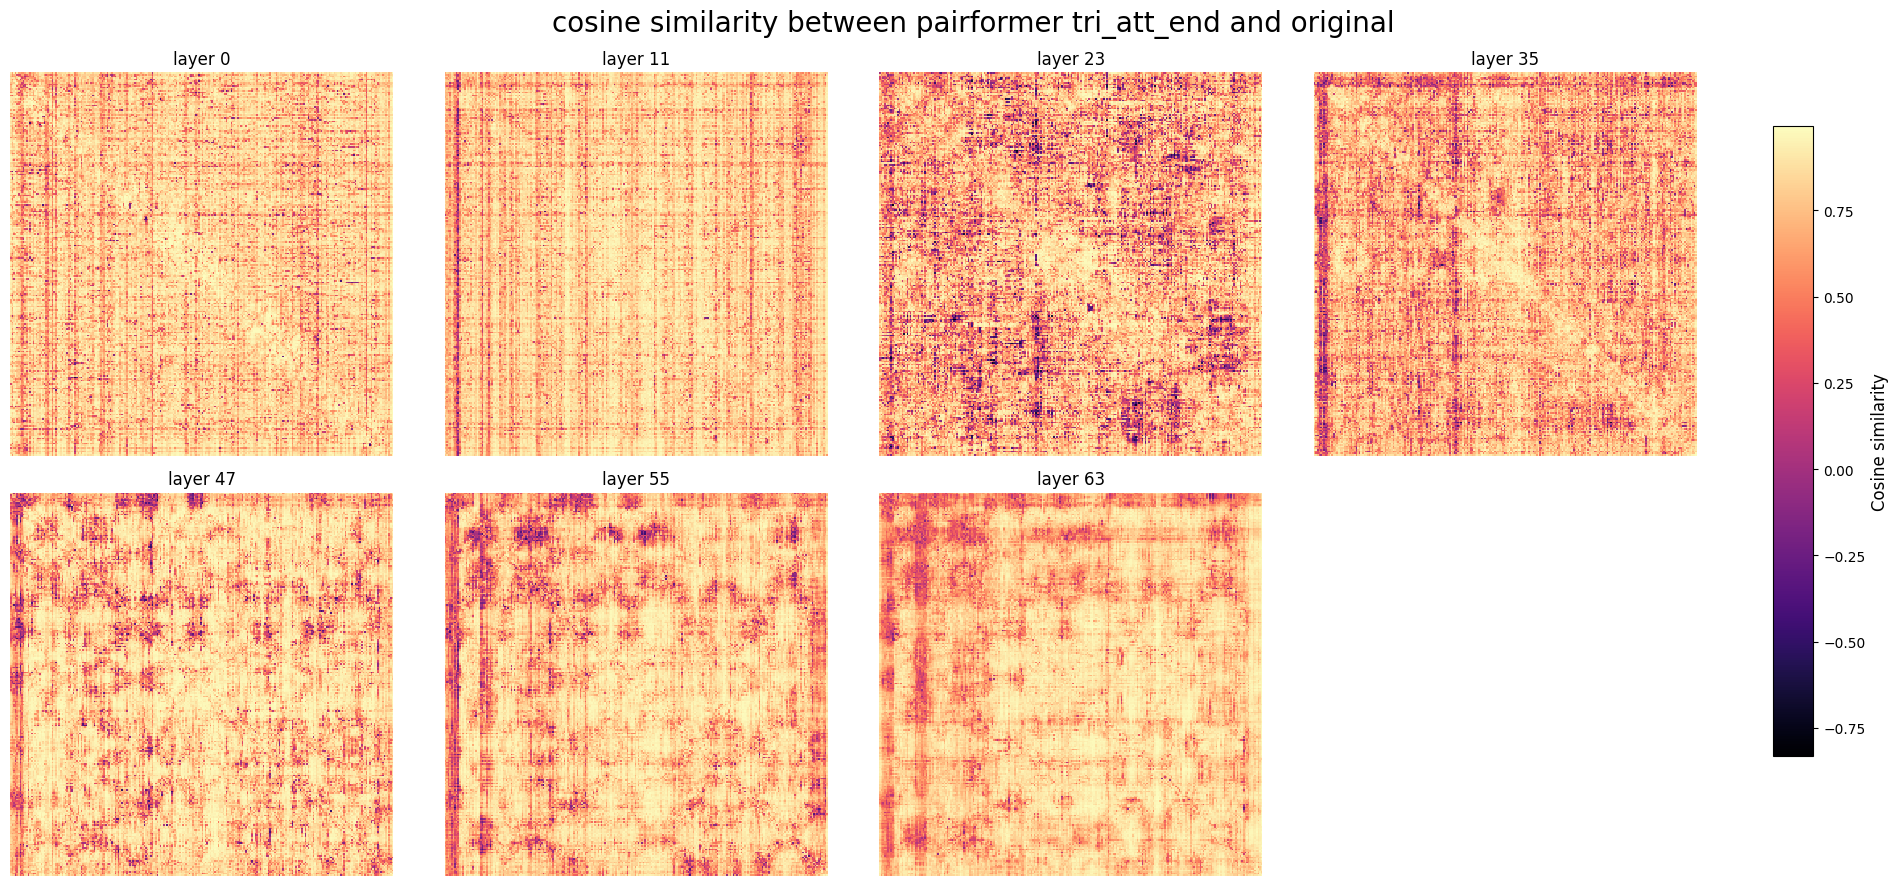

In [76]:
step = hidden_representations["step_0"]
step_original = original_rep["step_0"]

# Use 'pairformer_{i}_tri_att_end' keys for layer IDs instead of 'pairformer_{i}_tri_att_start'
layer_ids = sorted(
    {int(m.group(1)) for k in step if (m := re.match(r"pairformer_(\d+)_tri_att_end$", k))}
)

n = len(layer_ids)
ncols = min(n, 4)
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows), squeeze=False)

mats = []
for lid in layer_ids:
    m = step[f"pairformer_{lid}_tri_att_end"].squeeze(0)
    m_original = step_original[f"pairformer_{lid}_tri_att_end"].squeeze(0)
    cosine_similarity = (m * m_original).sum(dim=-1).cpu().numpy() / (m.norm(dim=-1).cpu().numpy() * m_original.norm(dim=-1).cpu().numpy())
    mats.append((lid, cosine_similarity))
vmin = min(cosine_similarity.min() for _, cosine_similarity in mats)
vmax = max(cosine_similarity.max() for _, cosine_similarity in mats)

cmap = 'magma'
norm = plt.Normalize(vmin, vmax)

# Draw heatmaps without colorbars, using same norm/cmap as the colorbar
for ax, (lid, diff) in zip(axes.flat, mats):
    sns.heatmap(diff, ax=ax, cbar=False, vmin=vmin, vmax=vmax, square=True,
                cmap=cmap, norm=norm, xticklabels=False, yticklabels=False)
    ax.set_title(f"layer {lid}")
for ax in axes.flat[len(mats):]:
    ax.axis("off")

# Add a dedicated colorbar to the figure, using the *same* cmap and norm as the heatmaps
import matplotlib as mpl
cbar_mappable = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar_mappable.set_array([])  # Required for Matplotlib >= 3.1

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = plt.colorbar(cbar_mappable, cax=cbar_ax)
cbar.set_label('Cosine similarity', fontsize=12)

fig.suptitle("cosine similarity between pairformer tri_att_end and original", fontsize=20)
# tight_layout does not always work with extra colorbar axes, so let's be gentle:
try:
    fig.tight_layout(rect=[0, 0, 0.88, 1])  # leave space for colorbar
except Exception as e:
    print(f"Warning (tight_layout): {e}")
plt.show()

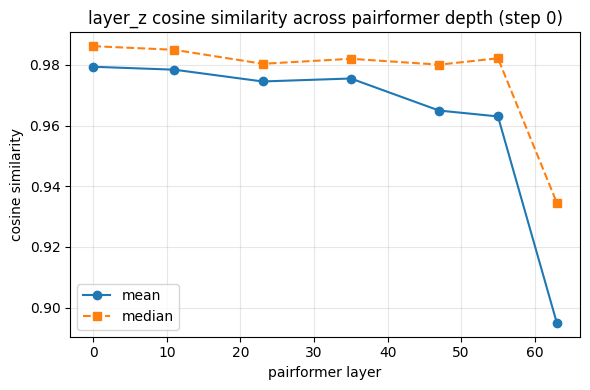

In [80]:
step = hidden_representations["step_0"]
step_original = original_rep["step_0"]
layer_ids = sorted(
    {int(m.group(1)) for k in step if (m := re.match(r"pairformer_(\d+)_layer_z$", k))}
)

mean_cosine_sim, median_cosine_sim = [], []
for lid in layer_ids:
    a = step[f"pairformer_{lid}_layer_z"].squeeze(0)
    b = step_original[f"pairformer_{lid}_layer_z"].squeeze(0)
    # Cosine similarity over last dimension
    nom = (a * b).sum(dim=-1)
    denom = a.norm(dim=-1) * b.norm(dim=-1)
    cosine_sim = (nom / denom).cpu().numpy()
    mean_cosine_sim.append(cosine_sim.mean())
    median_cosine_sim.append(np.median(cosine_sim))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(layer_ids, mean_cosine_sim, marker="o", label="mean")
ax.plot(layer_ids, median_cosine_sim, marker="s", linestyle="--", label="median")
ax.set_xlabel("pairformer layer")
ax.set_ylabel("cosine similarity")
ax.set_title("layer_z cosine similarity across pairformer depth (step 0)")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

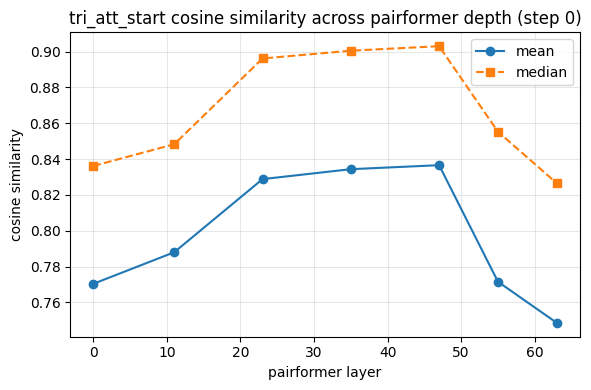

In [81]:
step = hidden_representations["step_5"]
step_original = original_rep["step_5"]
layer_ids = sorted(
    {int(m.group(1)) for k in step if (m := re.match(r"pairformer_(\d+)_tri_att_start$", k))}
)

mean_cosine_sim, median_cosine_sim = [], []
for lid in layer_ids:
    a = step[f"pairformer_{lid}_tri_att_start"].squeeze(0)
    b = step_original[f"pairformer_{lid}_tri_att_start"].squeeze(0)
    # Cosine similarity over last dimension
    nom = (a * b).sum(dim=-1)
    denom = a.norm(dim=-1) * b.norm(dim=-1)
    cosine_sim = (nom / denom).cpu().numpy()
    mean_cosine_sim.append(cosine_sim.mean())
    median_cosine_sim.append(np.median(cosine_sim))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(layer_ids, mean_cosine_sim, marker="o", label="mean")
ax.plot(layer_ids, median_cosine_sim, marker="s", linestyle="--", label="median")
ax.set_xlabel("pairformer layer")
ax.set_ylabel("cosine similarity")
ax.set_title("tri_att_start cosine similarity across pairformer depth (step 0)")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

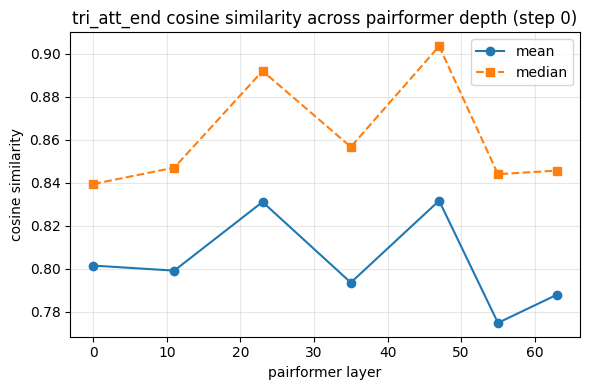

In [82]:
step = hidden_representations["step_5"]
step_original = original_rep["step_5"]
layer_ids = sorted(
    {int(m.group(1)) for k in step if (m := re.match(r"pairformer_(\d+)_tri_att_end$", k))}
)

mean_cosine_sim, median_cosine_sim = [], []
for lid in layer_ids:
    a = step[f"pairformer_{lid}_tri_att_end"].squeeze(0)
    b = step_original[f"pairformer_{lid}_tri_att_end"].squeeze(0)
    # Cosine similarity over last dimension
    nom = (a * b).sum(dim=-1)
    denom = a.norm(dim=-1) * b.norm(dim=-1)
    cosine_sim = (nom / denom).cpu().numpy()
    mean_cosine_sim.append(cosine_sim.mean())
    median_cosine_sim.append(np.median(cosine_sim))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(layer_ids, mean_cosine_sim, marker="o", label="mean")
ax.plot(layer_ids, median_cosine_sim, marker="s", linestyle="--", label="median")
ax.set_xlabel("pairformer layer")
ax.set_ylabel("cosine similarity")
ax.set_title("tri_att_end cosine similarity across pairformer depth (step 0)")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## Analysis with higher perturbation 

In [83]:
hidden_reps_40 = torch.load("/Users/thomasbush/Downloads/pairformer/p40/seq_00132/hidden_reps.pt")

In [157]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

LAYER_TYPES = ("layer_z", "tri_att_start", "tri_att_end")
_FNAME_RE = re.compile(r"seq_(\d+)__(?P<lt>layer_z|tri_att_start|tri_att_end)\.csv$")


def _load_dir(output_dir: Path) -> pd.DataFrame:
    """Concatenate all seq_*__{layer_type}.csv files in a directory."""
    frames = []
    for f in sorted(Path(output_dir).glob("seq_*__*.csv")):
        m = _FNAME_RE.search(f.name)
        if not m:
            continue
        df = pd.read_csv(f)
        df["layer_type"] = m.group("lt")
        df["seq"] = m.group(1)
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def plot_mean_cosine_across_layers(output_dirs, layer_types=LAYER_TYPES,
                                   show_band: bool = True, figsize_per: tuple = (6, 4.5)):
    """Plot mean cosine similarity across pairformer layers, one line per layer_type.

    output_dirs: a single Path/str or a list thereof. When multiple, a subplot is
    created per directory sharing the y-axis for easy comparison.
    """
    if isinstance(output_dirs, (str, Path)):
        output_dirs = [output_dirs]
    output_dirs = [Path(d) for d in output_dirs]

    n = len(output_dirs)
    fig, axes = plt.subplots(1, n,
                             figsize=(figsize_per[0] * n, figsize_per[1]),
                             sharey=True, squeeze=False)
    axes = axes[0]
    palette = dict(zip(layer_types, sns.color_palette("tab10", len(layer_types))))

    for ax, d in zip(axes, output_dirs):
        scores = _load_dir(d)
        if scores.empty:
            ax.set_visible(False)
            continue
        agg = (scores.groupby(["layer_type", "layer"])["mean"]
                      .agg(["mean", "std"]).reset_index())
        for lt in layer_types:
            sub = agg[agg.layer_type == lt].sort_values("layer")
            if sub.empty:
                continue
            ax.plot(sub.layer, sub["mean"], marker="o", color=palette[lt], label=lt)
            if show_band:
                ax.fill_between(sub.layer,
                                sub["mean"] - sub["std"],
                                sub["mean"] + sub["std"],
                                color=palette[lt], alpha=0.15)
        n_seqs = scores["seq"].nunique()
        ax.set_title(f"{d.name} (n={n_seqs})")
        ax.set_xlabel("pairformer layer")
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("mean cosine similarity")
    axes[-1].legend(loc="best")
    fig.tight_layout()
    return fig, axes


(<Figure size 1800x450 with 3 Axes>,
 array([<Axes: title={'center': 'step0 (n=100)'}, xlabel='pairformer layer', ylabel='mean cosine similarity'>,
        <Axes: title={'center': 'step5 (n=100)'}, xlabel='pairformer layer'>,
        <Axes: title={'center': 'step10 (n=100)'}, xlabel='pairformer layer'>],
       dtype=object))

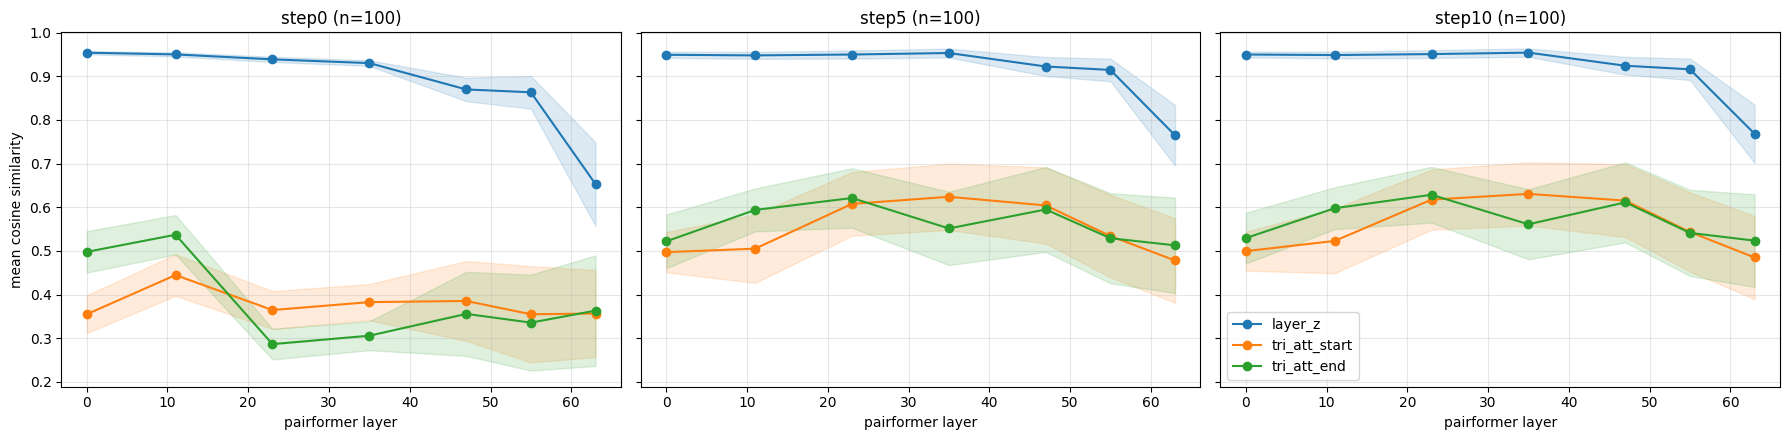

In [158]:
plot_mean_cosine_across_layers(
    [Path("/Users/thomasbush/Downloads/outputs_cosine_sim/p40/outputs_pairformer_sim/step0/"),
    Path("/Users/thomasbush/Downloads/outputs_cosine_sim/p40/outputs_pairformer_sim/step5/"),
    Path("/Users/thomasbush/Downloads/outputs_cosine_sim/p40/outputs_pairformer_sim/step10/")]
)

(<Figure size 1800x450 with 3 Axes>,
 array([<Axes: title={'center': 'step0 (n=100)'}, xlabel='pairformer layer', ylabel='mean cosine similarity'>,
        <Axes: title={'center': 'step5 (n=100)'}, xlabel='pairformer layer'>,
        <Axes: title={'center': 'step10 (n=100)'}, xlabel='pairformer layer'>],
       dtype=object))

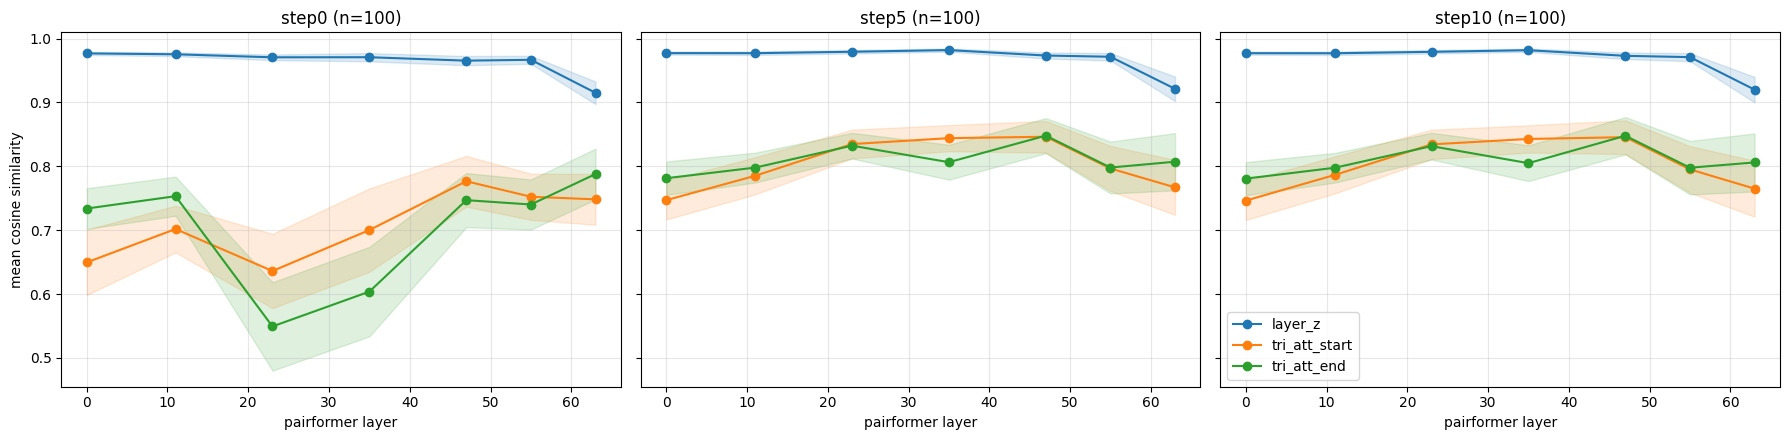

In [159]:
plot_mean_cosine_across_layers(
    [Path("/Users/thomasbush/Downloads/outputs_cosine_sim/p20/outputs_pairformer_sim/step0/"),
    Path("/Users/thomasbush/Downloads/outputs_cosine_sim/p20/outputs_pairformer_sim/step5/"),
    Path("/Users/thomasbush/Downloads/outputs_cosine_sim/p20/outputs_pairformer_sim/step10/")]
)

(<Figure size 1200x450 with 2 Axes>,
 array([<Axes: title={'center': 'step0 (n=100)'}, xlabel='pairformer layer', ylabel='mean cosine similarity'>,
        <Axes: title={'center': 'step4 (n=100)'}, xlabel='pairformer layer'>],
       dtype=object))

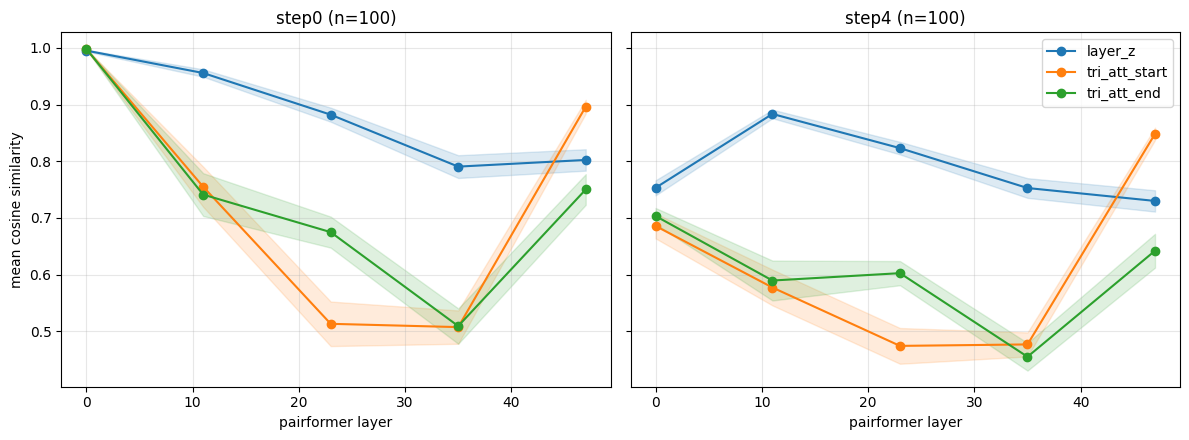

In [160]:
plot_mean_cosine_across_layers(
    [Path("/Users/thomasbush/Downloads/esm_pairformer_sim/p20/outputs_esm_sim/step0"),
    Path("/Users/thomasbush/Downloads/esm_pairformer_sim/p20/outputs_esm_sim/step4"),]
)

## Distance Metrics 

Cosine similarity between the the rows of the tri_att_start

In [172]:
original_tri_att = original_rep["step_0"]["pairformer_0_tri_att_start"].squeeze()
p40_tri_att = hidden_reps_40["step_0"]["pairformer_0_tri_att_start"].squeeze()

In [176]:
# now we can compute the row-wise cosine similarity 
# shape matrixes N_res x N_res x model_dim
scores = []

for i in range(original_tri_att.shape[0]):
    # we then extract each row: 
    ori = original_tri_att[i]
    p40 = p40_tri_att[i]
    score = torch.nn.functional.cosine_similarity(ori, p40, dim=-1)
    scores.append(score)

scores = torch.stack(scores)

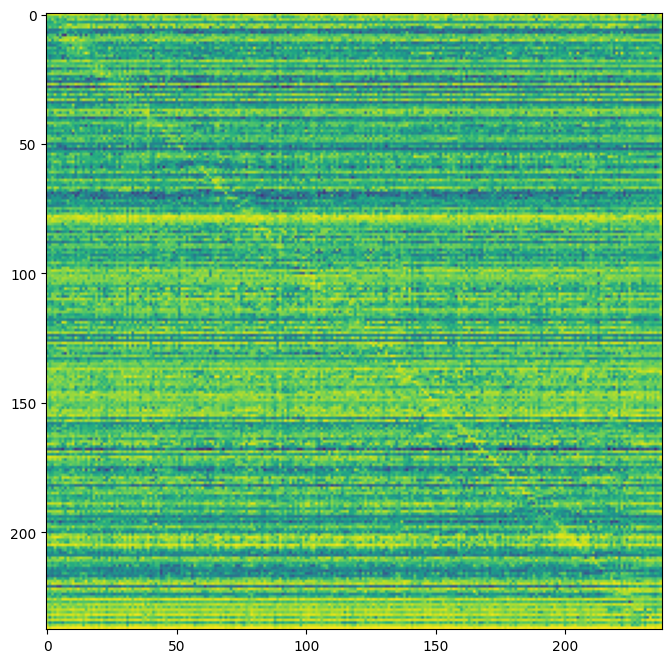

: 

In [ ]:
plt.figure(figsize=(10, 8))
plt.imshow(scores.cpu().numpy())
